# Project Delay Random Forest Feature Analysis

This notebook analyzes the flattened project feature table and trains customer-agnostic random forest models for project delay.

Targets:
- Continuous: `PERCENTDELAYED`
- Binary: delayed when `PERCENTDELAYED > 0`

Feature sets:
- **All non-label features**: diagnostic upper bound. Excludes direct identifiers and `CUSTOMERNAME`, but can include target-adjacent `TARGET*` fields.
- **Beginning-only features**: deployable-style set. Excludes target/posting/payment/actual fields, current project status, direct identifiers, and `CUSTOMERNAME`.

The raw text columns are excluded because their signal is represented by the keyword feature columns.

In [1]:
from __future__ import annotations

import hashlib
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import make_pipeline

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = Path('custpaydetails_project_feature_table_with_keywords_materialized_2026-06-09-1526_flat.csv')
TARGET = 'PERCENTDELAYED'
RANDOM_STATE = 20260609
TEST_FRACTION = 0.20

DATA_PATH, DATA_PATH.exists(), DATA_PATH.stat().st_size if DATA_PATH.exists() else None

(PosixPath('custpaydetails_project_feature_table_with_keywords_materialized_2026-06-09-1526_flat.csv'),
 True,
 74255146)

## Load Data And Target Profile

Raw shape: 5,762 rows x 6,075 columns
Rows with valid target: 3,469 / 5,762
Delayed rate: 52.2%


,PercentDelayed
count,3469.000000
mean,103.367586
std,406.538520
min,-99.716629
1%,-91.788008
5%,-90.683230
10%,-89.436620
25%,-80.263158
50%,16.228070
75%,168.115942


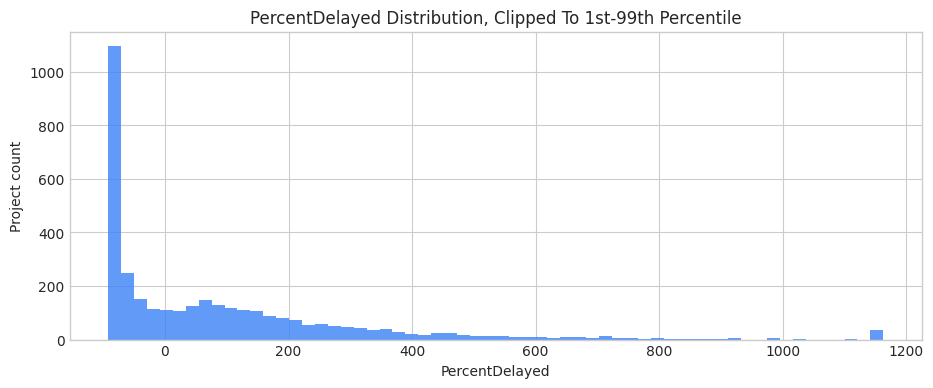

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Raw shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')

# Normalize Snowflake uppercase columns are already present. Keep column names as-is.
df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')
model_df = df[df[TARGET].notna()].copy()
model_df['DELAYED_BINARY'] = (model_df[TARGET] > 0).astype(int)

print(f'Rows with valid target: {len(model_df):,} / {len(df):,}')
print(f'Delayed rate: {model_df["DELAYED_BINARY"].mean():.1%}')
display(model_df[TARGET].describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]).to_frame('PercentDelayed'))

fig, ax = plt.subplots(figsize=(11, 4))
lo, hi = model_df[TARGET].quantile([.01, .99])
model_df[TARGET].clip(lo, hi).hist(bins=60, ax=ax, color='#3b82f6', alpha=.8)
ax.set_title('PercentDelayed Distribution, Clipped To 1st-99th Percentile')
ax.set_xlabel('PercentDelayed')
ax.set_ylabel('Project count')
plt.show()

## Feature Classification

`CUSTOMERNAME` is excluded from all feature sets. Raw text and direct identifiers are also excluded. Date columns are converted to ordinal numeric values. Keyword columns and all numeric project structure fields are retained.

In [3]:
ID_OR_TEXT_COLUMNS = {
    'RECORD_ID',
    'CUSTOMERNAME',
    'PROJECTID',
    'PROJECTNAME',
    'PROJECTCODE',
    'PROJECTDESCRIPTION',
}
BEGINNING_ONLY_EXCLUDE_EXACT = ID_OR_TEXT_COLUMNS | {TARGET, 'PROJECTSTATUS', 'DELAYED_BINARY'}
LEAKAGE_PREFIXES = ('TARGET',)
LEAKAGE_SUBSTRINGS = ('POSTING', 'PAYMENT', 'PAYESTIMATE', 'VALIDPOSTED', 'ACTUAL')

def is_date_like_name(col: str) -> bool:
    u = col.upper()
    return ('DATE' in u or 'STARTDATE' in u or 'ENDDATE' in u) and not col.endswith('_COUNT') and not col.endswith('_SHARE')

def is_beginning_safe(col: str) -> bool:
    u = col.upper()
    if col in BEGINNING_ONLY_EXCLUDE_EXACT:
        return False
    if u.startswith(LEAKAGE_PREFIXES):
        return False
    if any(s in u for s in LEAKAGE_SUBSTRINGS):
        return False
    return True

feature_work = model_df.copy()
date_cols = [c for c in feature_work.columns if is_date_like_name(c)]
for c in date_cols:
    parsed = pd.to_datetime(feature_work[c], errors='coerce')
    if parsed.notna().mean() >= 0.5:
        feature_work[c] = parsed.map(lambda x: x.toordinal() if pd.notna(x) else np.nan)

# Convert everything possible to numeric. Non-numeric text columns become all/mostly NaN and are filtered out.
numeric_frame = feature_work.apply(pd.to_numeric, errors='coerce')
nonmissing_rate = numeric_frame.notna().mean()
numeric_candidate_cols = [c for c in numeric_frame.columns if nonmissing_rate[c] > 0 and c not in {'DELAYED_BINARY'}]

all_feature_cols = [
    c for c in numeric_candidate_cols
    if c not in {TARGET, 'CUSTOMERNAME', 'RECORD_ID', 'PROJECTID'}
]
beginning_feature_cols = [c for c in all_feature_cols if is_beginning_safe(c)]

summary = pd.DataFrame({
    'count': [len(df.columns), len(numeric_candidate_cols), len(all_feature_cols), len(beginning_feature_cols)],
}, index=['all_columns', 'numeric_or_date_candidates', 'all_model_features', 'beginning_only_features'])
display(summary)

print('Date-like columns parsed/considered:', len(date_cols))
print('All feature examples:', all_feature_cols[:20])
print('Beginning-only feature examples:', beginning_feature_cols[:20])
print('Excluded from beginning examples:', [c for c in all_feature_cols if c not in beginning_feature_cols][:25])

missing_summary = pd.DataFrame({
    'all_features_missing_rate': [numeric_frame[all_feature_cols].isna().mean().mean()],
    'beginning_features_missing_rate': [numeric_frame[beginning_feature_cols].isna().mean().mean()],
})
display(missing_summary)

,count
all_columns,6075
numeric_or_date_candidates,6072
all_model_features,6069
beginning_only_features,6052


Date-like columns parsed/considered: 10
All feature examples: ['ABSPROJECTPLANNEDVALUE', 'BUDGETPLANNEDVALUESUM', 'CONTRACTSTARTSPREADDAYS', 'CONTRACT_KW_ABANDONMENT_CONTRACT_COUNT', 'CONTRACT_KW_ABANDONMENT_CONTRACT_SHARE', 'CONTRACT_KW_ABC_CONTRACT_COUNT', 'CONTRACT_KW_ABC_CONTRACT_SHARE', 'CONTRACT_KW_ABUTMENT_CONTRACT_COUNT', 'CONTRACT_KW_ABUTMENT_CONTRACT_SHARE', 'CONTRACT_KW_ACADEMY_CONTRACT_COUNT', 'CONTRACT_KW_ACADEMY_CONTRACT_SHARE', 'CONTRACT_KW_ACCESSIBILITY_CONTRACT_COUNT', 'CONTRACT_KW_ACCESSIBILITY_CONTRACT_SHARE', 'CONTRACT_KW_ACCESSIBLE_CONTRACT_COUNT', 'CONTRACT_KW_ACCESSIBLE_CONTRACT_SHARE', 'CONTRACT_KW_ACCESS_CONTRACT_COUNT', 'CONTRACT_KW_ACCESS_CONTRACT_SHARE', 'CONTRACT_KW_ADAMS_CONTRACT_COUNT', 'CONTRACT_KW_ADAMS_CONTRACT_SHARE', 'CONTRACT_KW_ADA_CONTRACT_COUNT']
Beginning-only feature examples: ['ABSPROJECTPLANNEDVALUE', 'BUDGETPLANNEDVALUESUM', 'CONTRACTSTARTSPREADDAYS', 'CONTRACT_KW_ABANDONMENT_CONTRACT_COUNT', 'CONTRACT_KW_ABANDONMENT_CONTRACT_SHARE', 'CONTRA

Excluded from beginning examples: ['ITEM_KW_PAYMENT_ITEM_COUNT', 'ITEM_KW_PAYMENT_ITEM_SHARE', 'PROJECTCODE', 'PROJECTDESCRIPTION', 'TARGETACTUALDURATIONDAYS', 'TARGETACTUALENDDATE', 'TARGETACTUALSTARTDATE', 'TARGETFIRSTPOSTINGDATE', 'TARGETLASTPOSTINGDATE', 'TARGETPAYMENTSPANDAYS', 'TARGETPLANNEDSTARTDATE', 'TARGETVALIDPOSTEDDETAILROWS', 'TARGETVALIDPOSTEDPAYDATECOUNT', 'TARGETVALIDPOSTEDPROJECTWORKCOMPLETEDAMOUNT', 'TARGETPLANNEDDURATIONDAYS', 'TARGETPLANNEDENDDATE', 'ITEM_KW_PAYMENT_PLANNED_VALUE_SHARE']


,all_features_missing_rate,beginning_features_missing_rate
0,0.065726,0.065601


## Hash-Based Train/Test Split

In [4]:
def hash_to_unit(value: str) -> float:
    return int(hashlib.md5(value.encode('utf-8')).hexdigest()[:8], 16) / 0xFFFFFFFF

split_key = (
    model_df.get('PROJECTID', '').astype(str) + '|' +
    model_df.get('PROJECTNAME', '').astype(str) + '|' +
    model_df.get('PROJECTCODE', '').astype(str)
)
test_mask = split_key.map(hash_to_unit).to_numpy() < TEST_FRACTION
train_mask = ~test_mask

y = numeric_frame[TARGET].to_numpy(dtype=float)
y_binary = model_df['DELAYED_BINARY'].to_numpy(dtype=int)
X_all = numeric_frame[all_feature_cols].astype('float32')
X_begin = numeric_frame[beginning_feature_cols].astype('float32')

split_summary = pd.DataFrame({
    'rows': [train_mask.sum(), test_mask.sum()],
    'delayed_rate': [y_binary[train_mask].mean(), y_binary[test_mask].mean()],
}, index=['train', 'test'])
display(split_summary)
print('X_all shape:', X_all.shape)
print('X_begin shape:', X_begin.shape)

,rows,delayed_rate
train,2799,0.525902
test,670,0.505970


X_all shape: (3469, 6069)
X_begin shape: (3469, 6052)


## Train Random Forest Models

In [5]:
def fit_regressor(X):
    model = make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestRegressor(
            n_estimators=180,
            min_samples_leaf=4,
            max_features='sqrt',
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    )
    model.fit(X.iloc[train_mask], y[train_mask])
    return model

def fit_classifier(X):
    model = make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestClassifier(
            n_estimators=220,
            min_samples_leaf=4,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    )
    model.fit(X.iloc[train_mask], y_binary[train_mask])
    return model

all_reg = fit_regressor(X_all)
all_clf = fit_classifier(X_all)
begin_reg = fit_regressor(X_begin)
begin_clf = fit_classifier(X_begin)
print('Models fitted.')

Models fitted.


## Model Metrics

In [6]:
def regression_metrics(name, model, X):
    pred = model.predict(X.iloc[test_mask])
    actual = y[test_mask]
    return {
        'model': name,
        'MAE': mean_absolute_error(actual, pred),
        'RMSE': math.sqrt(mean_squared_error(actual, pred)),
        'R2': r2_score(actual, pred),
        'Bias_PredMinusActual': float(np.mean(pred - actual)),
        'pred': pred,
        'actual': actual,
    }

def classification_metrics(name, model, X):
    prob = model.predict_proba(X.iloc[test_mask])[:, 1]
    pred = (prob >= 0.5).astype(int)
    actual = y_binary[test_mask]
    tn, fp, fn, tp = confusion_matrix(actual, pred, labels=[0, 1]).ravel()
    return {
        'model': name,
        'AUC': roc_auc_score(actual, prob),
        'Accuracy': accuracy_score(actual, pred),
        'BalancedAccuracy': balanced_accuracy_score(actual, pred),
        'Precision': precision_score(actual, pred, zero_division=0),
        'Recall': recall_score(actual, pred, zero_division=0),
        'F1': f1_score(actual, pred, zero_division=0),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'prob': prob,
        'actual': actual,
    }

reg_results = [
    regression_metrics('All features / diagnostic', all_reg, X_all),
    regression_metrics('Beginning-only / deployable-style', begin_reg, X_begin),
]
clf_results = [
    classification_metrics('All features / diagnostic', all_clf, X_all),
    classification_metrics('Beginning-only / deployable-style', begin_clf, X_begin),
]

reg_table = pd.DataFrame([{k: v for k, v in r.items() if k not in {'pred', 'actual'}} for r in reg_results])
clf_table = pd.DataFrame([{k: v for k, v in r.items() if k not in {'prob', 'actual'}} for r in clf_results])
display(reg_table)
display(clf_table)

,model,MAE,RMSE,R2,Bias_PredMinusActual
0,All features / diagnostic,92.513988,226.395899,0.414723,18.021026
1,Beginning-only / deployable-style,100.649599,232.051590,0.385115,19.404551


,model,AUC,Accuracy,BalancedAccuracy,Precision,Recall,F1,TP,FP,TN,FN
0,All features / diagnostic,0.986097,0.926866,0.926552,0.907303,0.952802,0.929496,323,33,298,16
1,Beginning-only / deployable-style,0.975448,0.914925,0.914539,0.891667,0.946903,0.918455,321,39,292,18


## Regression Diagnostics

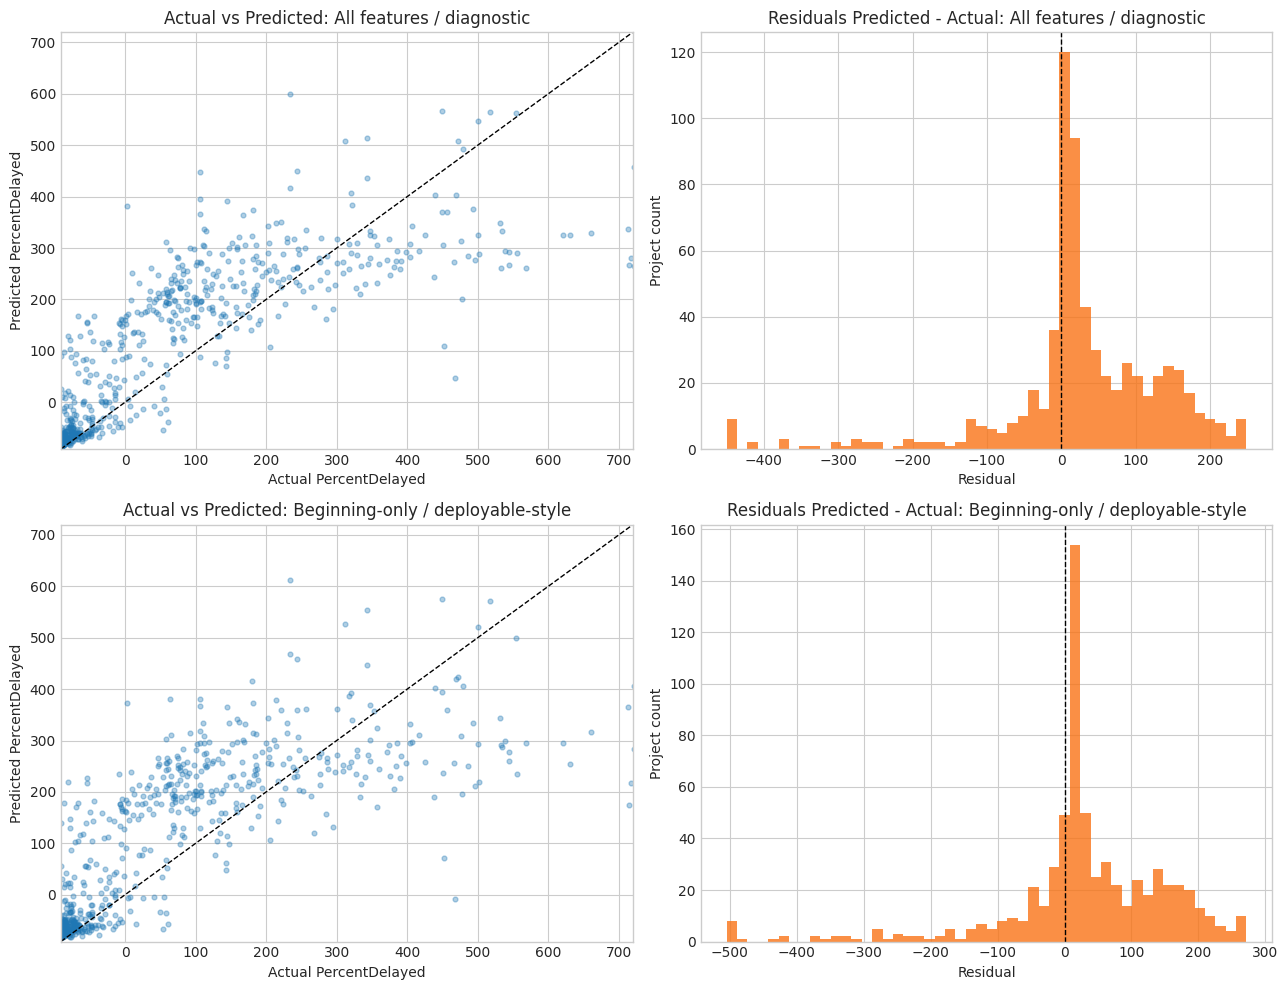

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for i, r in enumerate(reg_results):
    actual = r['actual']
    pred = r['pred']
    lo = np.nanpercentile(np.concatenate([actual, pred]), 1)
    hi = np.nanpercentile(np.concatenate([actual, pred]), 99)
    ax = axes[i, 0]
    ax.scatter(actual, pred, s=12, alpha=0.35)
    ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(f'Actual vs Predicted: {r["model"]}')
    ax.set_xlabel('Actual PercentDelayed')
    ax.set_ylabel('Predicted PercentDelayed')

    residual = pred - actual
    ax = axes[i, 1]
    lo_r, hi_r = np.nanpercentile(residual, [1, 99])
    ax.hist(np.clip(residual, lo_r, hi_r), bins=50, color='#f97316', alpha=0.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Residuals Predicted - Actual: {r["model"]}')
    ax.set_xlabel('Residual')
    ax.set_ylabel('Project count')
plt.tight_layout()
plt.show()

## Binary Classification Diagnostics

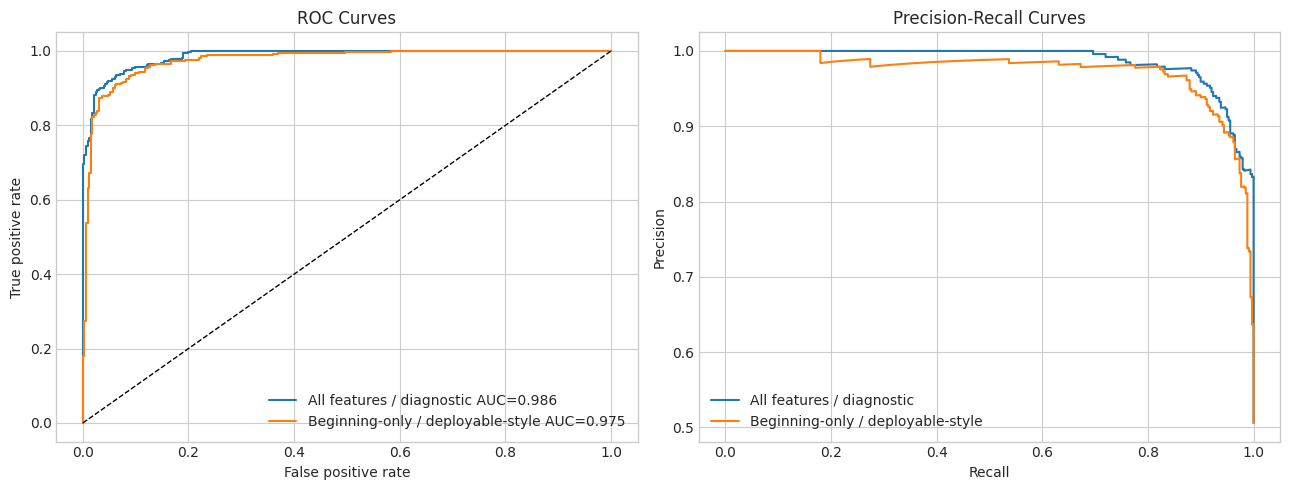

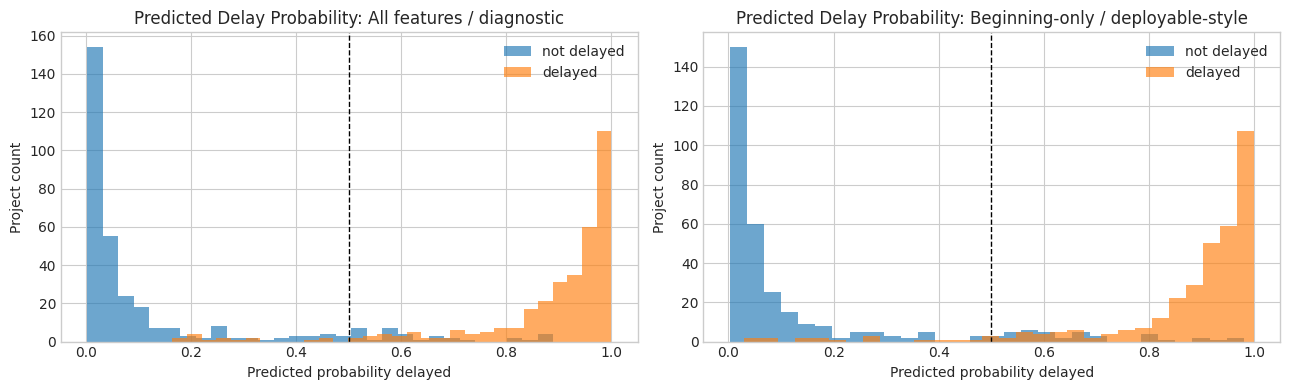

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for r in clf_results:
    fpr, tpr, _ = roc_curve(r['actual'], r['prob'])
    axes[0].plot(fpr, tpr, label=f"{r['model']} AUC={r['AUC']:.3f}")
    precision, recall, _ = precision_recall_curve(r['actual'], r['prob'])
    axes[1].plot(recall, precision, label=r['model'])
axes[0].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend()
axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, r in zip(axes, clf_results):
    ax.hist(r['prob'][r['actual'] == 0], bins=30, alpha=0.65, label='not delayed')
    ax.hist(r['prob'][r['actual'] == 1], bins=30, alpha=0.65, label='delayed')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Predicted Delay Probability: {r["model"]}')
    ax.set_xlabel('Predicted probability delayed')
    ax.set_ylabel('Project count')
    ax.legend()
plt.tight_layout()
plt.show()

## Feature Importances

feature  importance
model                                                                     
All regression 0                MAXCONTRACTPLANNEDDURATIONDAYS    0.029348
               1                      LOG1PPLANNEDDURATIONDAYS    0.025030
               2                     TARGETPLANNEDDURATIONDAYS    0.022618
               3                           PLANNEDDURATIONDAYS    0.019744
               4                      TARGETACTUALDURATIONDAYS    0.018819
               5                          DOLLARSPERPLANNEDDAY    0.017070
               6                         TARGETPAYMENTSPANDAYS    0.015028
               7                         TARGETACTUALSTARTDATE    0.014391
               8             MEDIANCONTRACTPLANNEDDURATIONDAYS    0.013579
               9                        DOLLARSPERPLANNEDMONTH    0.012508
               10                       STDDEVITEMPLANNEDVALUE    0.011672
               11                           DOLLARSPERCONTRACT    0.011348
               12  TARGETVALIDPOSTEDPROJECTWORKCOMPLETEDAMOUNT    0.010973
               13                   ITEM_KW_TRAFFIC_ITEM_SHARE    0.010662
               14                                 UNITPRICEP90    0.009702
               15                       ABSPROJECTPLANNEDVALUE    0.008796
               16               NUMDISTINCTSTANDARDITEMPREFIX3    0.008581
               17                              UNITPRICESTDDEV    0.007762
               18                       TARGETFIRSTPOSTINGDATE    0.007502
               19               NUMDISTINCTSTANDARDITEMPREFIX5    0.007460
               20        ITEM_KW_UNTREATED_PLANNED_VALUE_SHARE    0.007315
               21                         MEANITEMPLANNEDVALUE    0.007269
               22              ITEM_KW_MOBILIZATION_ITEM_SHARE    0.007215
               23                                 UNITPRICEMAX    0.006887
               24                              UNITPRICEMEDIAN    0.006654

feature  importance
model                                                                         
All classification 0                          DOLLARSPERPLANNEDDAY    0.026205
                   1                        ABSPROJECTPLANNEDVALUE    0.025551
                   2                        DOLLARSPERPLANNEDMONTH    0.025087
                   3                      TARGETACTUALDURATIONDAYS    0.022048
                   4                                  UNITPRICEP90    0.021377
                   5               ITEM_KW_MOBILIZATION_ITEM_SHARE    0.020681
                   6                     TARGETPLANNEDDURATIONDAYS    0.019890
                   7                MAXCONTRACTPLANNEDDURATIONDAYS    0.019176
                   8                NUMDISTINCTSTANDARDITEMPREFIX5    0.018697
                   9                      LOG1PPLANNEDDURATIONDAYS    0.018588
                   10              ITEM_KW_MOBILIZATION_ITEM_COUNT    0.017935
                   11                                 UNITPRICEMAX    0.017276
                   12                       MEDIANITEMPLANNEDVALUE    0.016937
                   13                              UNITPRICEMEDIAN    0.016306
                   14                          MAXITEMPLANNEDVALUE    0.015979
                   15  TARGETVALIDPOSTEDPROJECTWORKCOMPLETEDAMOUNT    0.015825
                   16                   ITEM_KW_CONTROL_ITEM_COUNT    0.015060
                   17                          PROJECTPLANNEDVALUE    0.013710
                   18                              UNITPRICESTDDEV    0.013420
                   19               NUMDISTINCTSTANDARDITEMPREFIX3    0.013346
                   20                           DOLLARSPERCONTRACT    0.013282
                   21                         MEANITEMPLANNEDVALUE    0.013204
                   22                  LOG1PABSPROJECTPLANNEDVALUE    0.012553
                   23         ITEM_KW_PAVEMENT_PLANNED_VALUE_SHARE    0.012454
                   24                          PLANNEDDURATIONDAYS    0.012367

feature  importance
model                                                                        
Beginning regression 0          MEDIANCONTRACTPLANNEDDURATIONDAYS    0.027460
                     1                        PLANNEDDURATIONDAYS    0.026035
                     2                   LOG1PPLANNEDDURATIONDAYS    0.020794
                     3             MAXCONTRACTPLANNEDDURATIONDAYS    0.020052
                     4                     DOLLARSPERPLANNEDMONTH    0.014977
                     5                     STDDEVITEMPLANNEDVALUE    0.014804
                     6                 SHAREZEROPLANNEDVALUEITEMS    0.013332
                     7             NUMDISTINCTSTANDARDITEMPREFIX5    0.012698
                     8                     MEDIANITEMPLANNEDVALUE    0.011497
                     9                               UNITPRICEP90    0.010769
                     10                           UNITPRICESTDDEV    0.010760
                     11            NUMDISTINCTSTANDARDITEMPREFIX3    0.009574
                     12                      DOLLARSPERPLANNEDDAY    0.009213
                     13                       MAXITEMPLANNEDVALUE    0.008860
                     14                      MEANITEMPLANNEDVALUE    0.008679
                     15                        DOLLARSPERCONTRACT    0.008425
                     16  ITEM_KW_MOBILIZATION_PLANNED_VALUE_SHARE    0.008054
                     17                    PROJ_KW_ADDITION_COUNT    0.007210
                     18                    ABSPROJECTPLANNEDVALUE    0.007035
                     19                ITEM_KW_TRAFFIC_ITEM_SHARE    0.006967
                     20           ITEM_KW_MOBILIZATION_ITEM_COUNT    0.006707
                     21                       PROJECTPLANNEDVALUE    0.006589
                     22    ITEM_KW_CORRUGATED_PLANNED_VALUE_SHARE    0.006564
                     23                    DOLLARSPERCONTRACTITEM    0.006493
                     24                ITEM_KW_TRAFFIC_ITEM_COUNT    0.006423

feature  importance
model                                                                     
Beginning classification 0                MEANITEMPLANNEDVALUE    0.028173
                         1          SHAREZEROPLANNEDVALUEITEMS    0.027066
                         2      NUMDISTINCTSTANDARDITEMPREFIX3    0.024645
                         3                        UNITPRICEP90    0.023540
                         4                DOLLARSPERPLANNEDDAY    0.023105
                         5              STDDEVITEMPLANNEDVALUE    0.022870
                         6          ITEM_KW_TRAFFIC_ITEM_COUNT    0.022737
                         7              DOLLARSPERPLANNEDMONTH    0.018262
                         8                 PLANNEDDURATIONDAYS    0.018094
                         9         LOG1PABSPROJECTPLANNEDVALUE    0.017617
                         10                    UNITPRICEMEDIAN    0.016706
                         11         ITEM_KW_CONTROL_ITEM_SHARE    0.016369
                         12             MEDIANITEMPLANNEDVALUE    0.016297
                         13             DOLLARSPERCONTRACTITEM    0.015541
                         14                    UNITPRICESTDDEV    0.015397
                         15  MEDIANCONTRACTPLANNEDDURATIONDAYS    0.015073
                         16     MAXCONTRACTPLANNEDDURATIONDAYS    0.014185
                         17                 DOLLARSPERCONTRACT    0.014147
                         18             PROJ_KW_ADDITION_COUNT    0.013821
                         19           LOG1PPLANNEDDURATIONDAYS    0.013352
                         20    ITEM_KW_MOBILIZATION_ITEM_COUNT    0.013195
                         21                MAXITEMPLANNEDVALUE    0.012611
                         22         ITEM_KW_ASPHALT_ITEM_COUNT    0.012437
                         23     NUMDISTINCTSTANDARDITEMPREFIX5    0.012048
                         24                       UNITPRICEMAX    0.011665

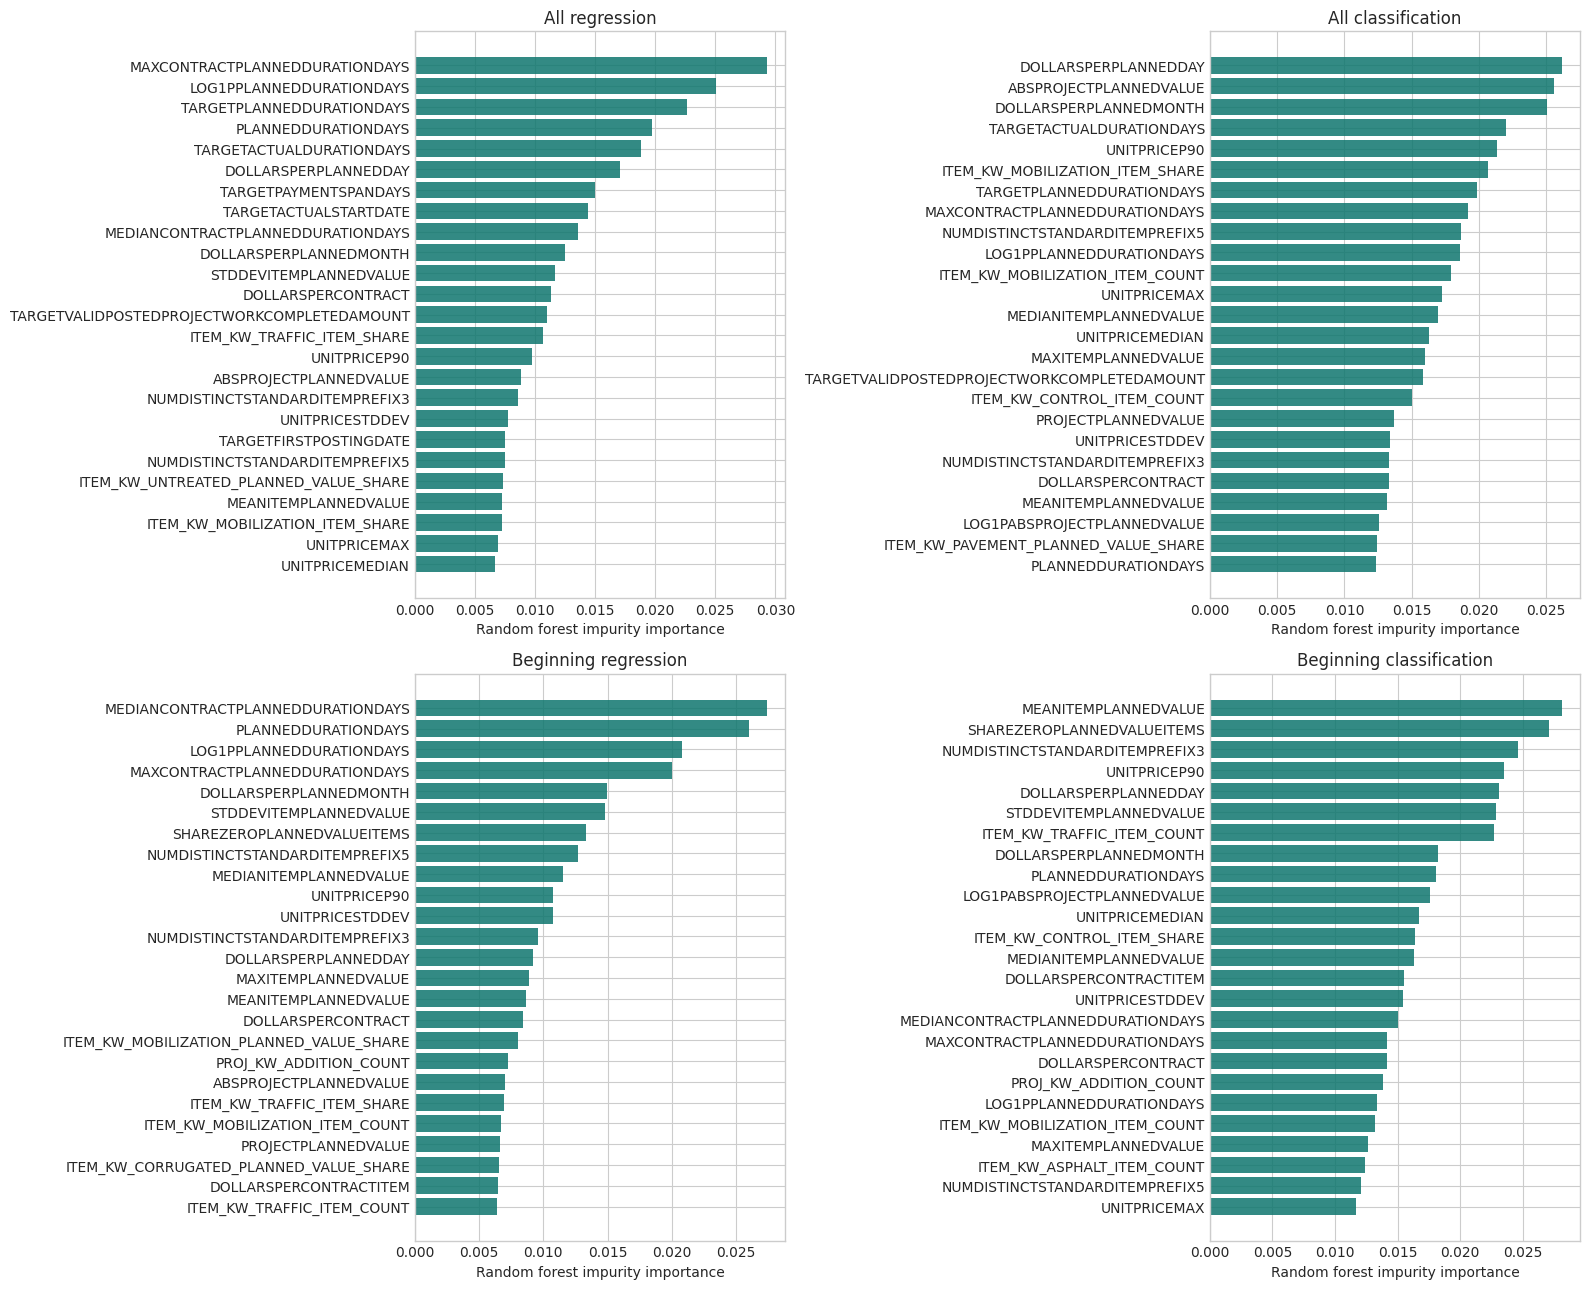

In [9]:
def feature_importance_table(model, feature_cols, top_n=30):
    rf = model.named_steps.get('randomforestregressor') or model.named_steps.get('randomforestclassifier')
    out = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
    return out.sort_values('importance', ascending=False).head(top_n).reset_index(drop=True)

importance_specs = [
    ('All regression', all_reg, all_feature_cols),
    ('All classification', all_clf, all_feature_cols),
    ('Beginning regression', begin_reg, beginning_feature_cols),
    ('Beginning classification', begin_clf, beginning_feature_cols),
]

importance_tables = {}
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
for ax, (title, model, cols) in zip(axes.ravel(), importance_specs):
    tbl = feature_importance_table(model, cols, 25)
    importance_tables[title] = tbl
    display(pd.concat({title: tbl}, names=['model']))
    ax.barh(tbl['feature'][::-1], tbl['importance'][::-1], color='#0f766e', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Random forest impurity importance')
plt.tight_layout()
plt.show()

## Beginning-Only Classifier Threshold Sweep

,threshold,precision,recall,f1,flag_rate
0,0.05,0.702083,0.994100,0.822955,0.716418
1,0.10,0.777262,0.988201,0.870130,0.643284
2,0.15,0.818182,0.982301,0.892761,0.607463
3,0.20,0.837975,0.976401,0.901907,0.589552
4,0.25,0.846154,0.973451,0.905350,0.582090
5,0.30,0.865079,0.964602,0.912134,0.564179
6,0.35,0.872000,0.964602,0.915966,0.559701
7,0.40,0.885870,0.961652,0.922207,0.549254
8,0.45,0.885246,0.955752,0.919149,0.546269
9,0.50,0.891667,0.946903,0.918455,0.537313


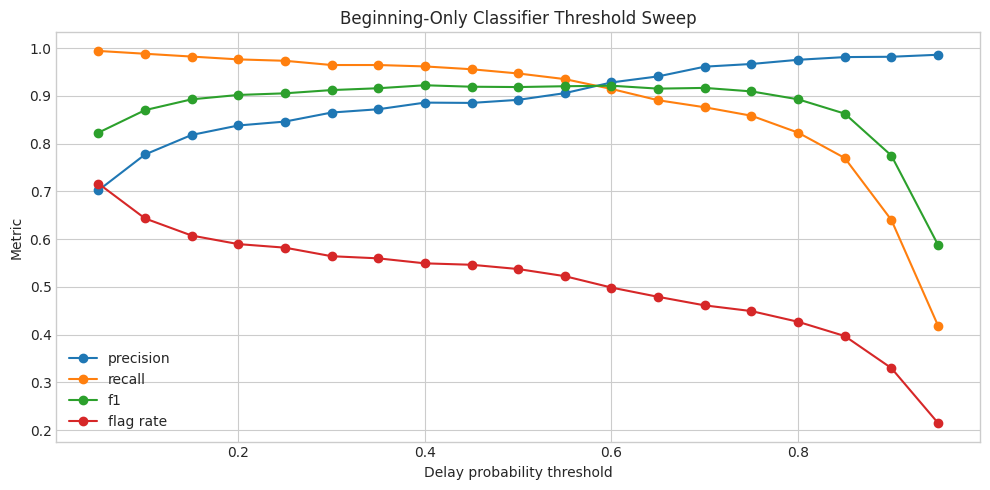

In [10]:
r = clf_results[1]
actual = r['actual']
prob = r['prob']
rows = []
for threshold in np.linspace(0.05, 0.95, 19):
    pred = (prob >= threshold).astype(int)
    rows.append({
        'threshold': threshold,
        'precision': precision_score(actual, pred, zero_division=0),
        'recall': recall_score(actual, pred, zero_division=0),
        'f1': f1_score(actual, pred, zero_division=0),
        'flag_rate': pred.mean(),
    })
threshold_df = pd.DataFrame(rows)
display(threshold_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='precision')
ax.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='recall')
ax.plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='f1')
ax.plot(threshold_df['threshold'], threshold_df['flag_rate'], marker='o', label='flag rate')
ax.set_title('Beginning-Only Classifier Threshold Sweep')
ax.set_xlabel('Delay probability threshold')
ax.set_ylabel('Metric')
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation Notes

The all-features model is a leakage-aware diagnostic upper bound. The beginning-only model is the more realistic pre-payment model because it excludes target/post-payment fields and customer identity.

Recommended follow-ups:
- Audit top keyword features for geography/customer proxy behavior even though `CUSTOMERNAME` is excluded.
- Run grouped validation by customer to test transfer to unseen customers.
- Consider long-form keyword modeling or dimensionality reduction if sparse keyword features dominate instability.
- Consider interval/quantile prediction for `PERCENTDELAYED`, since project delay is heavy-tailed.